# Calculus of Optimization for Machine Learning

> **Audience:** ML practitioners who want to understand *why* the math works, not just *how* to call the API.

---

##  Table of Contents
1. [Why Calculus in ML?](#why)
2. [Functions, Surfaces & Loss Landscapes](#loss)
3. [Derivatives — The Slope of a Curve](#derivatives)
4. [Partial Derivatives & Gradients](#gradients)
5. [The Chain Rule & Backpropagation](#chain)
6. [Gradient Descent — The Core Algorithm](#gd)
7. [Convexity & Critical Points](#convexity)
8. [Second-Order Methods (Newton's Method)](#second)
9. [Regularization Through a Calculus Lens](#regularization)
10. [End-to-End: Linear Regression from Scratch](#e2e)


---
## 1. Why Calculus in ML? <a id="why"></a>

Every ML model training loop boils down to **minimizing a loss function** $\mathcal{L}(\theta)$ over parameters $\theta$.

$$\theta^* = \arg\min_{\theta} \; \mathcal{L}(\theta)$$

Calculus gives us:
| Calculus Tool | ML Role |
|---|---|
| **Derivative / Gradient** | Direction of steepest ascent → tells us *which way to step* |
| **Chain Rule** | Backpropagation through layers |
| **Critical Points** | Where training converges ($\nabla \mathcal{L} = 0$) |
| **Hessian (2nd order)** | Curvature → adaptive optimizers (Adam, RMSProp) |
| **Taylor Expansion** | Justifies small learning-rate steps |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print("✅ Libraries loaded.")


✅ Libraries loaded.


---
## 2. Functions, Surfaces & Loss Landscapes <a id="loss"></a>

A model with parameters $(w_1, w_2)$ defines a **loss surface** — a 3-D bowl (or rugged terrain) we want to navigate to the bottom.

$$\mathcal{L}(w_1, w_2) = \text{some scalar quantity we want to minimize}$$

Below we visualise three archetypal surfaces: **convex bowl** (ideal), **saddle point**, and a **multi-modal** landscape (deep nets).


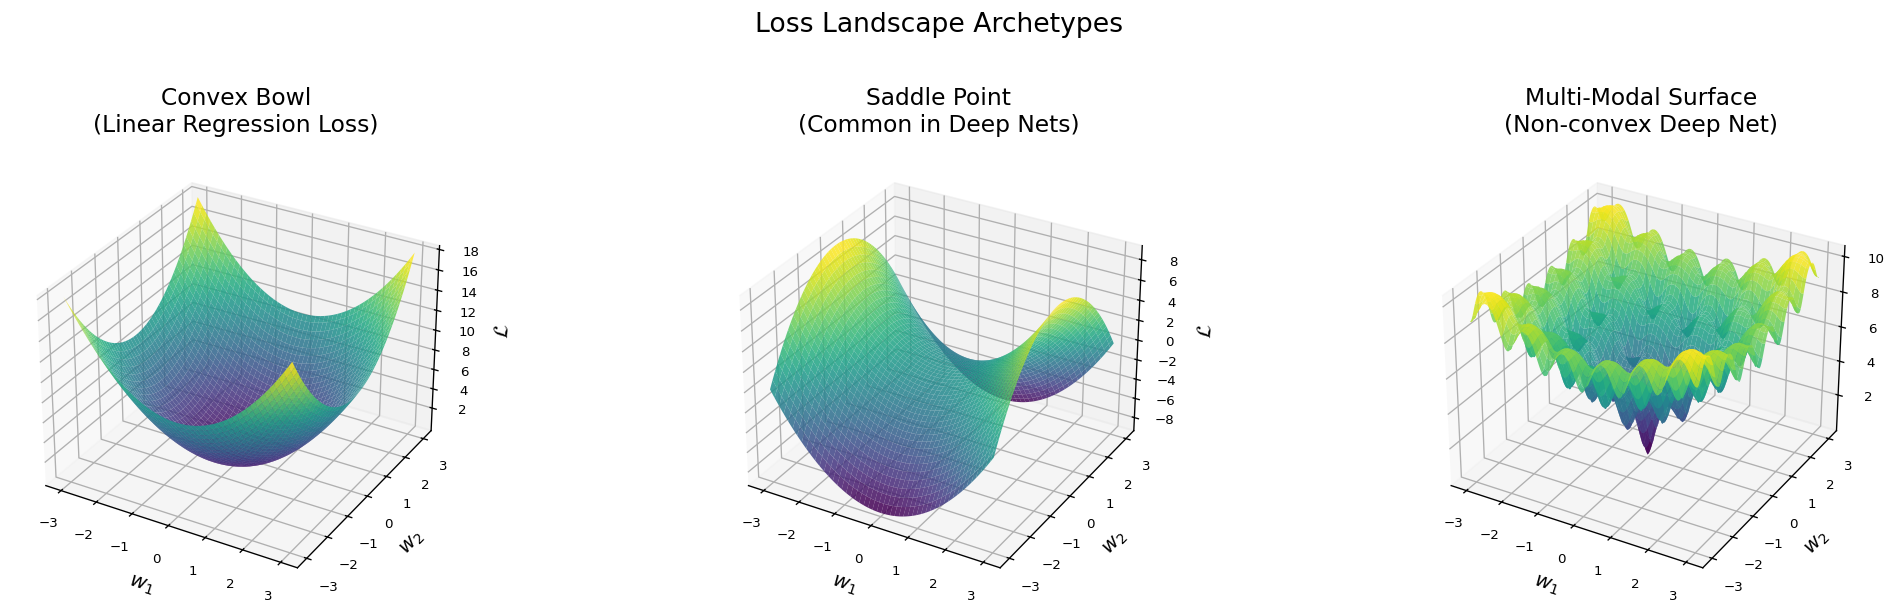

In [2]:
fig = plt.figure(figsize=(18, 5))

w = np.linspace(-3, 3, 200)
W1, W2 = np.meshgrid(w, w)

# 1. Convex bowl
Z1 = W1**2 + W2**2

# 2. Saddle
Z2 = W1**2 - W2**2

# 3. Multi-modal (Ackley-like simplified)
Z3 = -20*np.exp(-0.2*np.sqrt(0.5*(W1**2 + W2**2)))      - np.exp(0.5*(np.cos(2*np.pi*W1) + np.cos(2*np.pi*W2))) + np.e + 20

titles = ["Convex Bowl\n(Linear Regression Loss)", 
          "Saddle Point\n(Common in Deep Nets)",
          "Multi-Modal Surface\n(Non-convex Deep Net)"]
surfaces = [Z1, Z2, Z3]

for i, (Z, title) in enumerate(zip(surfaces, titles)):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_surface(W1, W2, Z, cmap=cm.viridis, alpha=0.85, linewidth=0)
    ax.set_title(title, pad=10)
    ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$'); ax.set_zlabel('$\mathcal{L}$')
    ax.tick_params(labelsize=8)

plt.suptitle("Loss Landscape Archetypes", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


---
## 3. Derivatives — The Slope of a Curve <a id="derivatives"></a>

### Definition

The derivative of $f(x)$ at a point $x$ is the **instantaneous rate of change**:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

### Geometric Interpretation
The derivative is the **slope of the tangent line** at a point.

### Key Rules (used constantly in ML)

| Rule | Formula |
|---|---|
| Power | $\frac{d}{dx} x^n = n x^{n-1}$ |
| Chain | $\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$ |
| Product | $\frac{d}{dx}[f \cdot g] = f'g + fg'$ |
| Log | $\frac{d}{dx} \ln(x) = \frac{1}{x}$ |
| Exponential | $\frac{d}{dx} e^x = e^x$ |
| Sigmoid | $\sigma'(x) = \sigma(x)(1 - \sigma(x))$ |

### In ML: MSE Loss for one parameter $w$

$$\mathcal{L}(w) = \frac{1}{n}\sum_{i=1}^n (y_i - w x_i)^2 \implies \frac{d\mathcal{L}}{dw} = \frac{-2}{n}\sum_{i=1}^n x_i(y_i - w x_i)$$


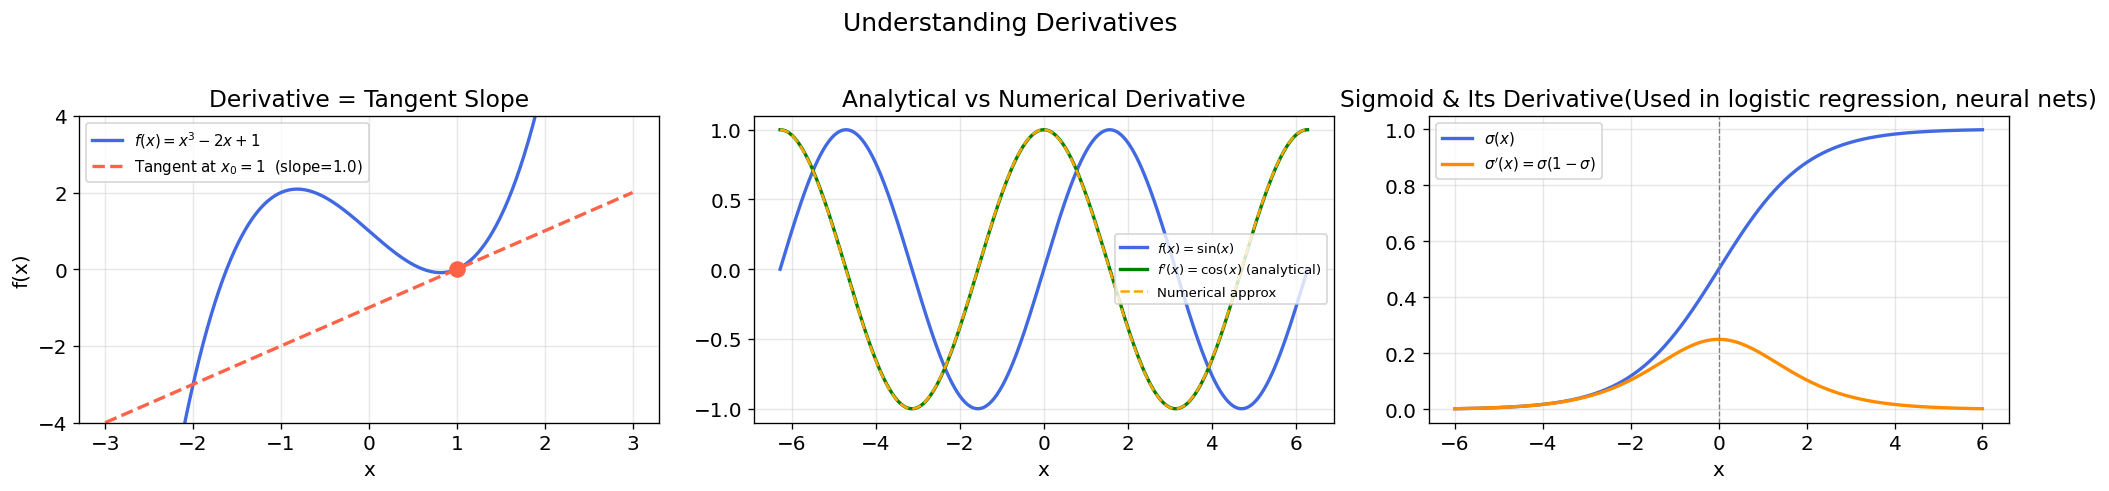

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# ── Plot 1: derivative as tangent line ──
x = np.linspace(-3, 3, 400)
f = x**3 - 2*x + 1
x0 = 1.0
f0 = x0**3 - 2*x0 + 1
slope = 3*x0**2 - 2            # f'(x) = 3x²-2
tangent = f0 + slope*(x - x0)

ax = axes[0]
ax.plot(x, f, label='$f(x) = x^3 - 2x + 1$', color='royalblue')
ax.plot(x, tangent, '--', color='tomato', label=f'Tangent at $x_0=1$  (slope={slope:.1f})')
ax.scatter([x0], [f0], s=80, zorder=5, color='tomato')
ax.set_ylim(-4, 4); ax.set_title("Derivative = Tangent Slope")
ax.legend(fontsize=9); ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# ── Plot 2: numerical vs analytical derivative ──
x = np.linspace(-2*np.pi, 2*np.pi, 400)
f_sin  = np.sin(x)
df_sin = np.cos(x)               # analytical

h = 0.01
df_num = (np.sin(x + h) - np.sin(x)) / h  # numerical

ax = axes[1]
ax.plot(x, f_sin,  label='$f(x) = \sin(x)$',      color='royalblue')
ax.plot(x, df_sin, label="$f'(x) = \cos(x)$ (analytical)", color='green')
ax.plot(x, df_num, '--', label="Numerical approx",    color='orange', lw=1.5)
ax.set_title("Analytical vs Numerical Derivative")
ax.legend(fontsize=8); ax.set_xlabel('x')

# ── Plot 3: sigmoid and its derivative ──
x = np.linspace(-6, 6, 400)
sigmoid   = 1 / (1 + np.exp(-x))
d_sigmoid = sigmoid * (1 - sigmoid)

ax = axes[2]
ax.plot(x, sigmoid,   label='$\sigma(x)$',           color='royalblue')
ax.plot(x, d_sigmoid, label="$\sigma'(x) = \sigma(1-\sigma)$", color='darkorange')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_title("Sigmoid & Its Derivative(Used in logistic regression, neural nets)")
ax.legend(fontsize=9); ax.set_xlabel('x')

plt.suptitle("Understanding Derivatives", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Partial Derivatives & Gradients <a id="gradients"></a>

When a loss depends on **multiple parameters** $(w_1, w_2, \ldots, w_n)$, we take a **partial derivative** with respect to each, holding the others fixed:

$$\frac{\partial \mathcal{L}}{\partial w_j} = \lim_{h \to 0} \frac{\mathcal{L}(\ldots, w_j+h, \ldots) - \mathcal{L}(\ldots, w_j, \ldots)}{h}$$

### The Gradient Vector

The **gradient** $\nabla_{\theta}\mathcal{L}$ stacks all partial derivatives into a single vector:

$$\nabla_{\theta}\mathcal{L} = \begin{bmatrix} \frac{\partial \mathcal{L}}{\partial w_1} \\ \frac{\partial \mathcal{L}}{\partial w_2} \\ \vdots \\ \frac{\partial \mathcal{L}}{\partial w_n} \end{bmatrix}$$

> **Key Insight:** The gradient **points in the direction of steepest ascent**. To minimise the loss, we step in the **opposite** direction.


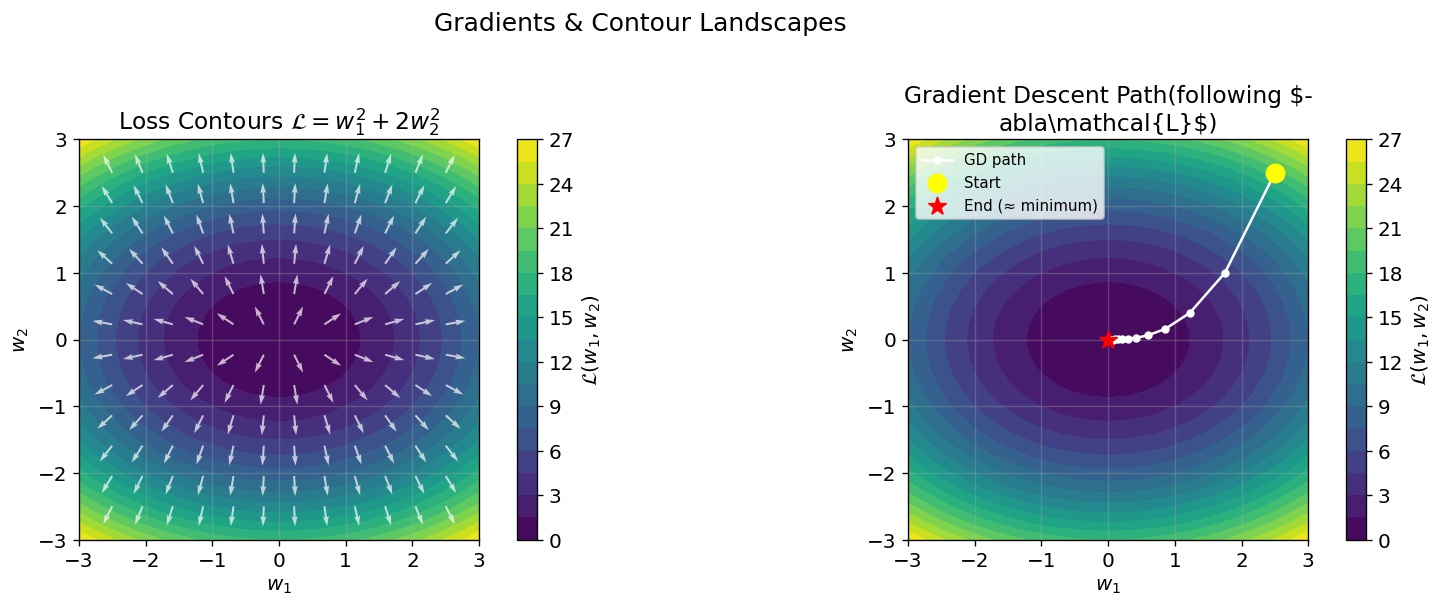

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Contour + gradient field ──
w = np.linspace(-3, 3, 300)
W1, W2 = np.meshgrid(w, w)
Z = W1**2 + 2*W2**2            # elliptic bowl

ax = axes[0]
cp = ax.contourf(W1, W2, Z, levels=25, cmap='viridis')
fig.colorbar(cp, ax=ax, label='$\mathcal{L}(w_1, w_2)$')
ax.set_title("Loss Contours $\mathcal{L} = w_1^2 + 2w_2^2$")
ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')

# Gradient arrows on a coarser grid
ws = np.linspace(-2.5, 2.5, 12)
G1, G2 = np.meshgrid(ws, ws)
dL_dw1 = 2*G1    # ∂L/∂w1
dL_dw2 = 4*G2    # ∂L/∂w2
# Normalise for display
mag = np.sqrt(dL_dw1**2 + dL_dw2**2) + 1e-6
ax.quiver(G1, G2, dL_dw1/mag, dL_dw2/mag, color='white', alpha=0.7, scale=20)
ax.set_aspect('equal')

# ── Gradient descent path on contour ──
ax2 = axes[1]
cp2 = ax2.contourf(W1, W2, Z, levels=25, cmap='viridis')
fig.colorbar(cp2, ax=ax2, label='$\mathcal{L}(w_1, w_2)$')
ax2.set_title("Gradient Descent Path(following $-\nabla\mathcal{L}$)")

# Simulate GD
lr = 0.15
w_cur = np.array([2.5, 2.5])
path = [w_cur.copy()]
for _ in range(30):
    grad = np.array([2*w_cur[0], 4*w_cur[1]])
    w_cur = w_cur - lr * grad
    path.append(w_cur.copy())
path = np.array(path)

ax2.plot(path[:,0], path[:,1], 'o-', color='white', markersize=4, lw=1.5, label='GD path')
ax2.scatter(*path[0], s=120, color='yellow', zorder=5, label='Start')
ax2.scatter(*path[-1], s=120, color='red', zorder=5, marker='*', label='End (≈ minimum)')
ax2.set_xlabel('$w_1$'); ax2.set_ylabel('$w_2$')
ax2.legend(fontsize=9)
ax2.set_aspect('equal')

plt.suptitle("Gradients & Contour Landscapes", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


---
## 5. The Chain Rule & Backpropagation <a id="chain"></a>

### The Chain Rule

If $z = f(y)$ and $y = g(x)$, then:

$$\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}$$

For **composition of many functions** (a neural network!):

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial a^{(L)}} \cdot \frac{\partial a^{(L)}}{\partial z^{(L)}} \cdot \frac{\partial z^{(L)}}{\partial a^{(L-1)}} \cdots \frac{\partial z^{(1)}}{\partial w}$$

### A 2-Layer Network Example

| Layer | Operation | Derivative |
|---|---|---|
| Linear | $z = wx + b$ | $\partial z / \partial w = x$ |
| Sigmoid | $a = \sigma(z)$ | $\partial a / \partial z = \sigma(z)(1-\sigma(z))$ |
| MSE Loss | $\mathcal{L} = (a - y)^2$ | $\partial \mathcal{L} / \partial a = 2(a-y)$ |

**Full gradient via chain rule:**
$$\frac{\partial \mathcal{L}}{\partial w} = 2(a-y) \cdot \sigma(z)(1-\sigma(z)) \cdot x$$

> This is exactly what `loss.backward()` does in PyTorch — automatically!


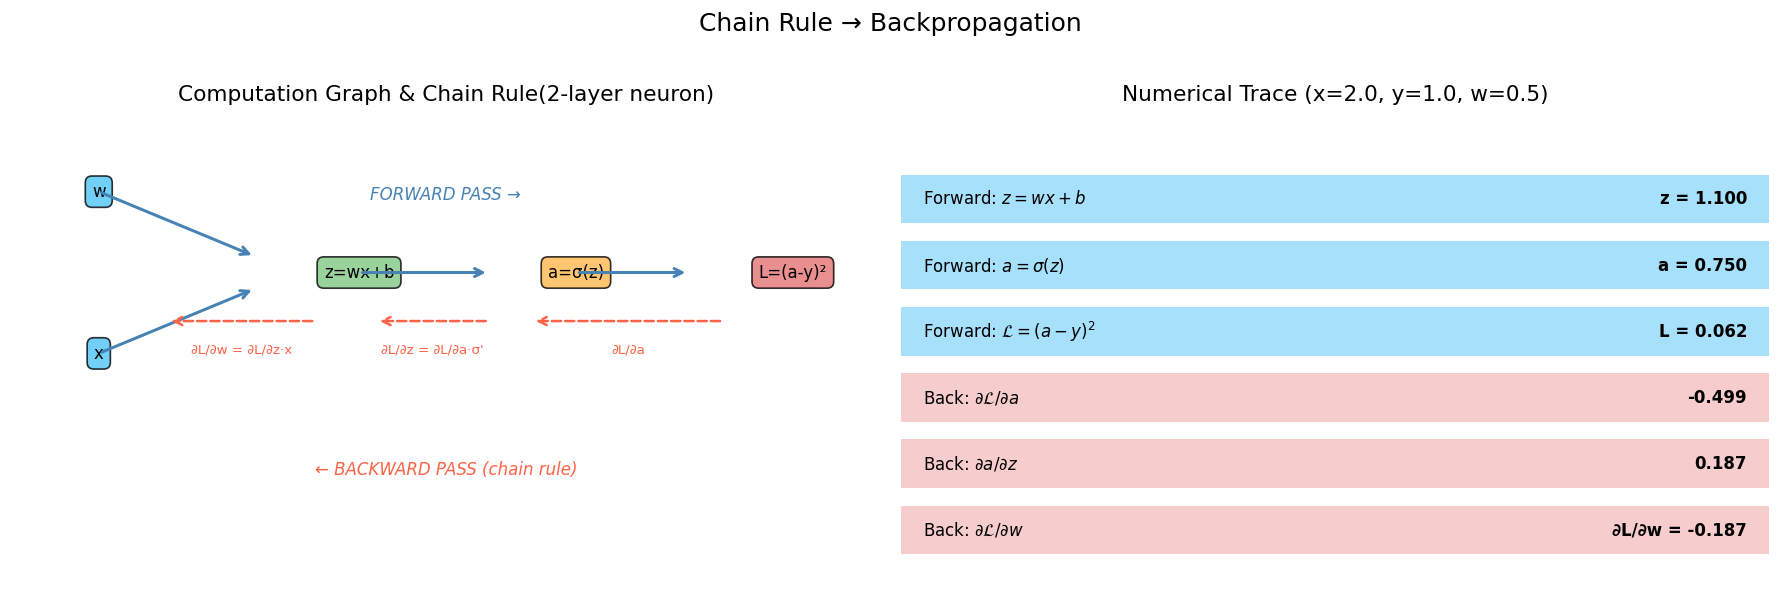

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel 1: computation graph ──
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title("Computation Graph & Chain Rule(2-layer neuron)", fontsize=13)

nodes = {'x': (1,3), 'w': (1,5), 'z=wx+b': (4,4), 'a=σ(z)': (6.5,4), 'L=(a-y)²': (9,4)}
colors = ['#4fc3f7','#4fc3f7','#81c784','#ffb74d','#e57373']
for (name, pos), col in zip(nodes.items(), colors):
    ax.annotate('', xy=pos, xytext=pos)
    ax.text(*pos, name, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=col, alpha=0.8))

# arrows forward
edges = [('x',(2.8,3.8)), ('w',(2.8,4.2)), ('z=wx+b',(5.5,4)), ('a=σ(z)',(7.8,4))]
for src, tgt in edges:
    ax.annotate("", xy=tgt, xytext=nodes[src],
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.8))

# backward arrows (red, dashed)
back = [((8.2,3.4),(6.0,3.4)), ((5.5,3.4),(4.2,3.4)), ((3.5,3.4),(1.8,3.4))]
labels_back = ["∂L/∂a", "∂L/∂z = ∂L/∂a·σ'", "∂L/∂w = ∂L/∂z·x"]
for (start, end), lbl in zip(back, labels_back):
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5, linestyle='dashed'))
    mx, my = (start[0]+end[0])/2, start[1]-0.4
    ax.text(mx, my, lbl, ha='center', fontsize=8, color='tomato')

ax.text(5, 1.5, "← BACKWARD PASS (chain rule)", ha='center', fontsize=10, color='tomato', style='italic')
ax.text(5, 4.9, "FORWARD PASS →", ha='center', fontsize=10, color='steelblue', style='italic')

# ── Panel 2: manual backprop on a sample ──
ax2 = axes[1]

x_val = 2.0; y_val = 1.0; w_val = 0.5; b_val = 0.1
z_val = w_val*x_val + b_val
sig   = 1/(1+np.exp(-z_val))
loss  = (sig - y_val)**2

dL_da = 2*(sig - y_val)
da_dz = sig*(1 - sig)
dz_dw = x_val
dL_dw = dL_da * da_dz * dz_dw

steps = ['Forward: $z = wx+b$', 'Forward: $a = \sigma(z)$', 'Forward: $\mathcal{L}=(a-y)^2$',
         'Back: $\partial\mathcal{L}/\partial a$', 'Back: $\partial a/\partial z$',
         'Back: $\partial\mathcal{L}/\partial w$']
vals  = [f'z = {z_val:.3f}', f'a = {sig:.3f}', f'L = {loss:.3f}',
         f'{dL_da:.3f}', f'{da_dz:.3f}', f'∂L/∂w = {dL_dw:.3f}']
colors2 = ['#4fc3f7']*3 + ['#ef9a9a']*3

for i, (s, v, c) in enumerate(zip(steps, vals, colors2)):
    y_pos = 5 - i*0.75
    ax2.barh(y_pos, 8, height=0.55, color=c, alpha=0.5, left=0)
    ax2.text(0.2, y_pos, s, va='center', fontsize=10)
    ax2.text(7.8, y_pos, v, va='center', ha='right', fontsize=10, fontweight='bold')

ax2.set_xlim(0, 8); ax2.set_ylim(0.5, 6)
ax2.axis('off')
ax2.set_title(f"Numerical Trace (x={x_val}, y={y_val}, w={w_val})", fontsize=13)

plt.suptitle("Chain Rule → Backpropagation", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Gradient Descent — The Core Algorithm <a id="gd"></a>

### Update Rule

$$\theta_{t+1} = \theta_t - \eta \; \nabla_{\theta} \mathcal{L}(\theta_t)$$

where $\eta$ (eta) is the **learning rate** — the step size.

### Variants

| Variant | Data per step | Notes |
|---|---|---|
| **Batch GD** | Full dataset | Exact gradient, slow per step |
| **Stochastic GD (SGD)** | 1 sample | Noisy but fast, can escape saddles |
| **Mini-batch GD** | $B$ samples | Best of both worlds (default in practice) |

### Why does the learning rate matter?

- **Too large** $\eta$: overshoots the minimum, diverges  
- **Too small** $\eta$: converges very slowly  
- **Just right**: smooth convergence


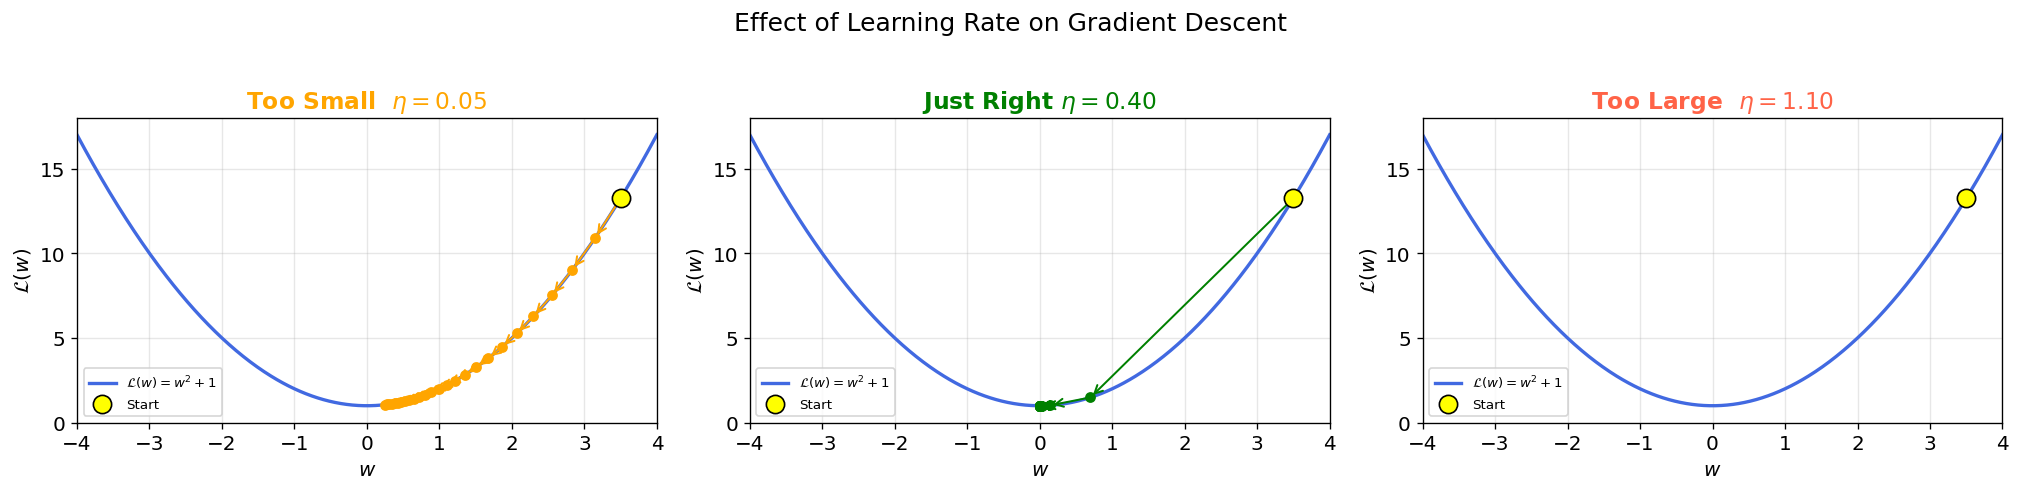

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

x_vals = np.linspace(-4, 4, 500)
f_vals = x_vals**2 + 1   # simple 1D loss: L(w) = w² + 1, dL/dw = 2w

def gd_1d(w0, lr, steps=20):
    w, path = w0, [w0]
    for _ in range(steps):
        w = w - lr * 2*w
        path.append(w)
    return np.array(path)

configs = [
    (0.05, 'Too Small  $\eta=0.05$', 'orange'),
    (0.4,  'Just Right $\eta=0.40$', 'green'),
    (1.1,  'Too Large  $\eta=1.10$', 'tomato'),
]

for ax, (lr, title, col) in zip(axes, configs):
    path = gd_1d(3.5, lr, steps=25)
    ax.plot(x_vals, f_vals, 'royalblue', lw=2, label='$\mathcal{L}(w) = w^2+1$')
    
    # plot steps
    for i in range(len(path)-1):
        wi, wn = path[i], path[i+1]
        fi, fn  = wi**2+1, wn**2+1
        ax.annotate("", xy=(wn, fn), xytext=(wi, fi),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.2))
    
    ax.scatter(path, path**2+1, s=30, color=col, zorder=5)
    ax.scatter(path[0], path[0]**2+1, s=120, color='yellow', edgecolor='k', zorder=6, label='Start')
    ax.set_title(title, color=col, fontweight='bold')
    ax.set_xlabel('$w$'); ax.set_ylabel('$\mathcal{L}(w)$')
    ax.legend(fontsize=8)
    ax.set_xlim(-4,4); ax.set_ylim(0, 18)

plt.suptitle("Effect of Learning Rate on Gradient Descent", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


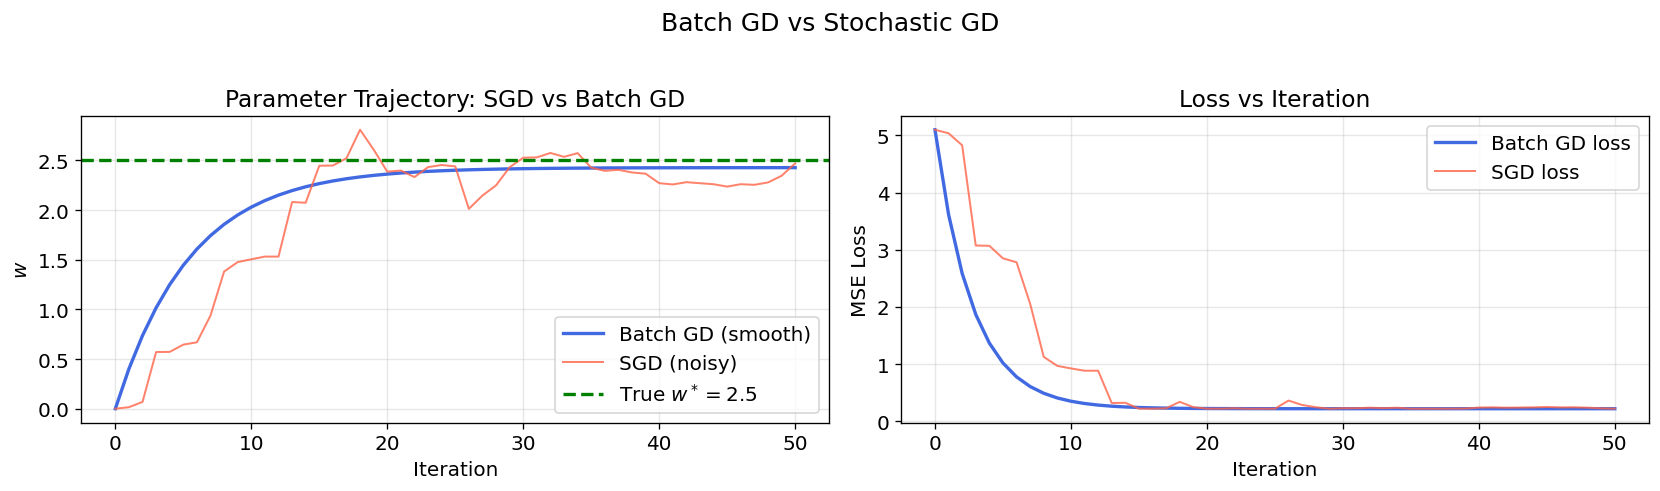

In [11]:
# ── SGD vs Batch GD noise comparison ──
np.random.seed(42)
n = 100
X_true = np.random.randn(n)
Y_true = 2.5*X_true + np.random.randn(n)*0.5   # ground truth w=2.5

def loss_and_grad(w, X, Y):
    preds = w * X
    L = np.mean((preds - Y)**2)
    g = np.mean(2*(preds - Y)*X)
    return L, g

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full batch
w, lr = 0.0, 0.1
batch_path = [w]
for _ in range(50):
    _, g = loss_and_grad(w, X_true, Y_true)
    w -= lr * g
    batch_path.append(w)

# SGD (batch size = 1)
w = 0.0
sgd_path = [w]
for _ in range(50):
    i = np.random.randint(n)
    _, g = loss_and_grad(w, X_true[[i]], Y_true[[i]])
    w -= lr * g
    sgd_path.append(w)

axes[0].plot(batch_path, label='Batch GD (smooth)', color='royalblue', lw=2)
axes[0].plot(sgd_path, label='SGD (noisy)', color='tomato', lw=1.2, alpha=0.8)
axes[0].axhline(2.5, ls='--', color='green', label='True $w^*=2.5$')
axes[0].set_title("Parameter Trajectory: SGD vs Batch GD")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("$w$")
axes[0].legend()

# Loss curves
batch_loss = [(loss_and_grad(w, X_true, Y_true)[0]) for w in batch_path]
sgd_loss   = [(loss_and_grad(w, X_true, Y_true)[0]) for w in sgd_path]
axes[1].plot(batch_loss, label='Batch GD loss', color='royalblue', lw=2)
axes[1].plot(sgd_loss,   label='SGD loss', color='tomato', lw=1.2, alpha=0.8)
axes[1].set_title("Loss vs Iteration")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.suptitle("Batch GD vs Stochastic GD", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


---
## 7. Convexity & Critical Points <a id="convexity"></a>

### Critical Points: Where $\nabla\mathcal{L} = 0$

| Point Type | $f'(x)=0$? | $f''(x)$ | ML Impact |
|---|---|---|---|
| **Local Minimum** | ✅ | $> 0$ | Safe landing zone |
| **Local Maximum** | ✅ | $< 0$ | Very rare in high-D |
| **Saddle Point** | ✅ | Mixed | Common in deep nets, slows training |
| **Global Minimum** | ✅ | $> 0$ | The goal! |

### Convexity Condition

A function is **convex** if for all $x, y$ and $\lambda \in [0,1]$:

$$f(\lambda x + (1-\lambda)y) \leq \lambda f(x) + (1-\lambda) f(y)$$

Equivalently: $f''(x) \geq 0$ everywhere (the Hessian $H \succeq 0$).

> **Convex** loss → any local minimum is the global minimum → **linear/logistic regression** enjoy this property!  
> **Deep networks** are **non-convex**, but empirically GD still finds good solutions.


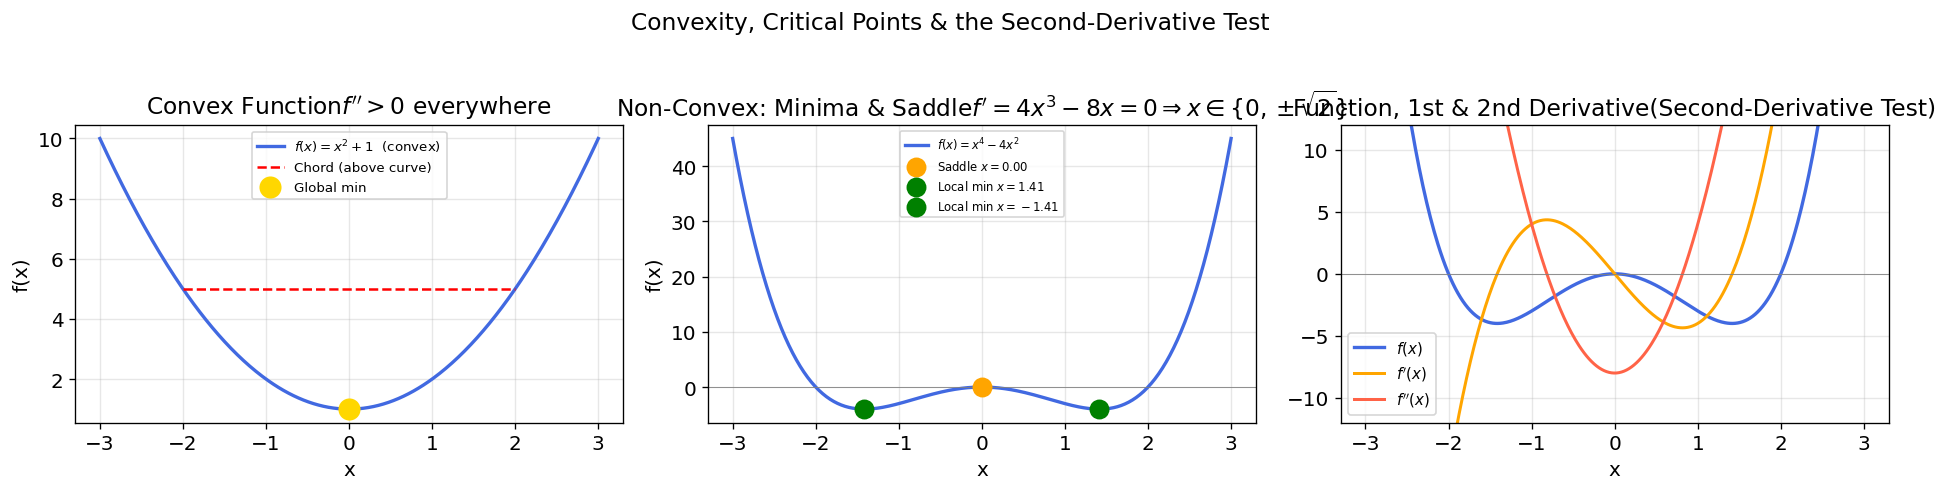

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x = np.linspace(-3, 3, 400)

# ── 1. Convex ──
f1 = x**2 + 1
ax = axes[0]
ax.plot(x, f1, 'royalblue', lw=2, label='$f(x) = x^2+1$  (convex)')
# chord
xa, xb = -2, 2
ax.plot([xa,xb], [xa**2+1, xb**2+1], 'r--', lw=1.5, label='Chord (above curve)')
ax.scatter([0],[1], s=150, color='gold', zorder=5, label='Global min')
ax.set_title("Convex Function$f\'\' > 0$ everywhere"); ax.legend(fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# ── 2. Non-convex with saddle ──
f2 = x**4 - 4*x**2
df2 = 4*x**3 - 8*x    # f'
ddf2 = 12*x**2 - 8    # f''
ax = axes[1]
ax.plot(x, f2, 'royalblue', lw=2, label="$f(x)=x^4-4x^2$")
ax.axhline(0, color='gray', lw=0.5)
# critical points: f'=0 -> x=0, ±√2
for xc, kind, col in [(0,'Saddle','orange'), (np.sqrt(2),'Local min','green'), (-np.sqrt(2),'Local min','green')]:
    ax.scatter([xc],[xc**4-4*xc**2], s=120, color=col, zorder=5, label=f'{kind} $x={xc:.2f}$')
ax.set_title("Non-Convex: Minima & Saddle$f\'=4x^3-8x=0 \Rightarrow x\in\{0, \pm\sqrt{2}\}$")
ax.legend(fontsize=7); ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# ── 3. 2nd derivative test ──
ax = axes[2]
ax.plot(x, f2,  'royalblue', lw=2, label="$f(x)$")
ax.plot(x, df2, 'orange',    lw=1.8, label="$f'(x)$")
ax.plot(x, ddf2,'tomato',    lw=1.8, label="$f''(x)$")
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylim(-12,12)
ax.set_title("Function, 1st & 2nd Derivative(Second-Derivative Test)")
ax.legend(fontsize=9); ax.set_xlabel('x')

plt.suptitle("Convexity, Critical Points & the Second-Derivative Test", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 8. Second-Order Methods (Newton's Method) <a id="second"></a>

Gradient descent only uses **first-order** information (slope). Newton's method also uses **curvature** (the Hessian $H$):

$$\theta_{t+1} = \theta_t - H^{-1}\nabla\mathcal{L}(\theta_t)$$

where the **Hessian** is the matrix of second-order partial derivatives:

$$H_{ij} = \frac{\partial^2 \mathcal{L}}{\partial w_i \partial w_j}$$

### Intuition via Taylor Expansion

$$\mathcal{L}(\theta + \Delta\theta) \approx \mathcal{L}(\theta) + \nabla\mathcal{L}^\top \Delta\theta + \frac{1}{2}\Delta\theta^\top H \Delta\theta$$

Setting the derivative to zero gives the Newton step: $\Delta\theta = -H^{-1}\nabla\mathcal{L}$.

### Why Adaptive Optimizers?

**Adam** approximates the diagonal of $H^{-1}$ cheaply using first and second moment estimates of the gradients — getting curvature-aware steps without expensive matrix inversion.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t \quad (\text{1st moment}) $$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2 \quad (\text{2nd moment})$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t}+\epsilon} \hat{m}_t$$


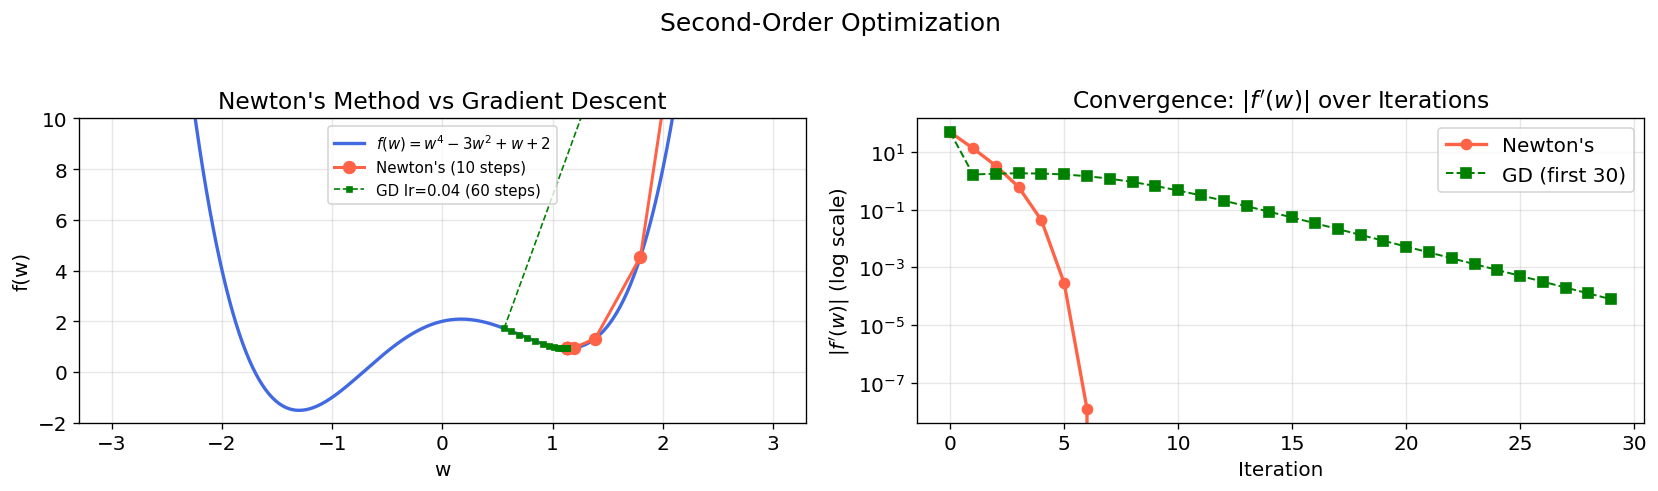

In [14]:
# Compare GD vs Newton on a 1D example
x = np.linspace(-3, 3, 400)
f  = lambda w: w**4 - 3*w**2 + w + 2
df = lambda w: 4*w**3 - 6*w + 1
ddf= lambda w: 12*w**2 - 6

def run_newton(w0, steps=10):
    w, path = w0, [w0]
    for _ in range(steps):
        w = w - df(w)/ddf(w)
        path.append(w)
    return np.array(path)

def run_gd(w0, lr=0.05, steps=60):
    w, path = w0, [w0]
    for _ in range(steps):
        w = w - lr*df(w)
        path.append(w)
    return np.array(path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

w0 = 2.5
path_n = run_newton(w0, 10)
path_g = run_gd(w0, 0.04, 60)

# Panel 1: function with trajectories
ax = axes[0]
ax.plot(x, f(x), 'royalblue', lw=2, label='$f(w) = w^4-3w^2+w+2$')
ax.plot(path_n, f(path_n), 'o-', color='tomato', lw=1.8, ms=7, label=f"Newton's (10 steps)")
ax.plot(path_g, f(path_g), 's--', color='green', lw=1, ms=3, label=f'GD lr=0.04 (60 steps)')
ax.set_title("Newton's Method vs Gradient Descent")
ax.set_xlabel('w'); ax.set_ylabel('f(w)'); ax.legend(fontsize=9)
ax.set_ylim(-2, 10)

# Panel 2: convergence of |f'(w)|
ax2 = axes[1]
ax2.semilogy([abs(df(w)) for w in path_n], 'o-', color='tomato', label="Newton's")
ax2.semilogy([abs(df(w)) for w in path_g[:30]], 's--', color='green', lw=1.2, label='GD (first 30)')
ax2.set_title("Convergence: $|f\'(w)|$ over Iterations")
ax2.set_xlabel('Iteration'); ax2.set_ylabel("$|f'(w)|$ (log scale)")
ax2.legend()

plt.suptitle("Second-Order Optimization", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


---
## 9. Regularization Through a Calculus Lens <a id="regularization"></a>

Regularization **modifies the loss** to penalise large weights, preventing overfitting. This changes the gradient and therefore the update rule.

### L2 Regularization (Ridge)

$$\mathcal{L}_{\text{reg}}(\theta) = \mathcal{L}(\theta) + \frac{\lambda}{2}\|\theta\|^2$$

$$\nabla\mathcal{L}_{\text{reg}} = \nabla\mathcal{L} + \lambda\theta$$

The update becomes: $\theta \leftarrow \theta(1 - \eta\lambda) - \eta\nabla\mathcal{L}$ → **weight decay**.

### L1 Regularization (Lasso)

$$\mathcal{L}_{\text{reg}}(\theta) = \mathcal{L}(\theta) + \lambda\|\theta\|_1$$

$$\nabla\mathcal{L}_{\text{reg}} = \nabla\mathcal{L} + \lambda \cdot \text{sign}(\theta)$$

L1 drives weights **exactly to zero** (sparsity) because its gradient is constant regardless of weight magnitude.


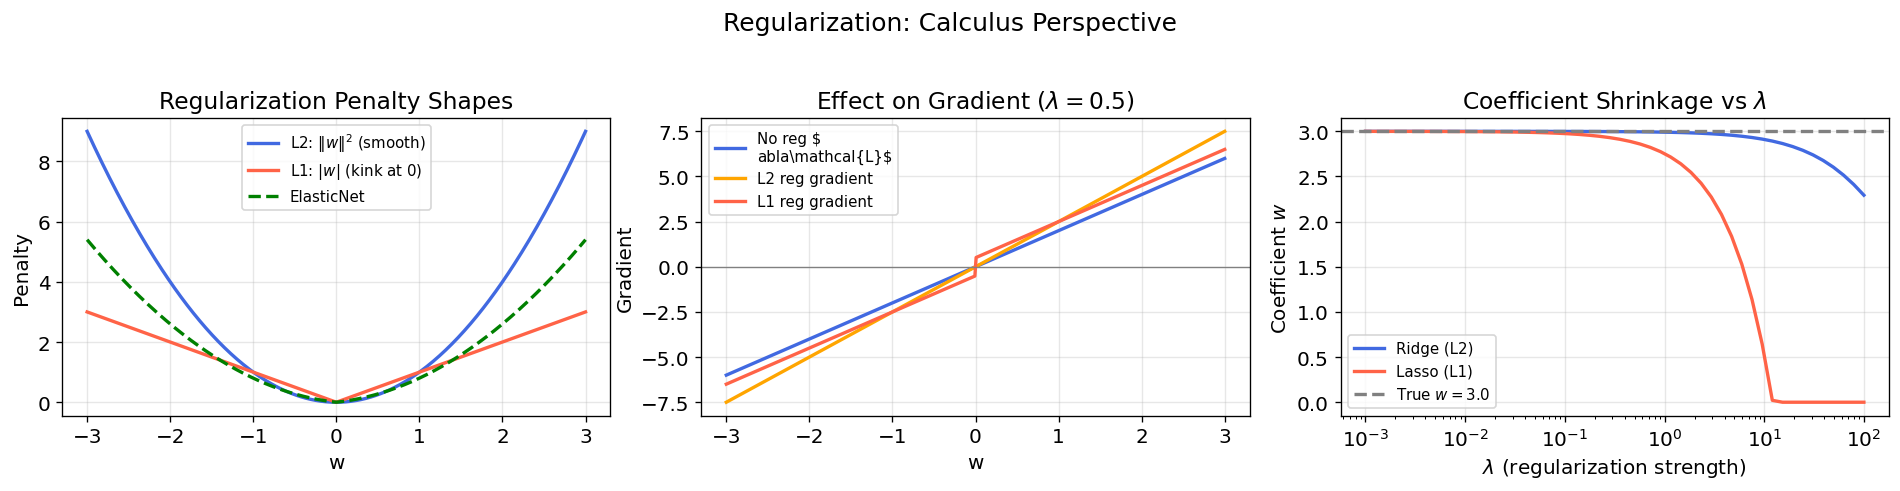

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
w = np.linspace(-3, 3, 400)

# ── Penalty shapes ──
ax = axes[0]
ax.plot(w, w**2,         'royalblue', lw=2, label='L2: $\|w\|^2$ (smooth)')
ax.plot(w, np.abs(w),    'tomato',    lw=2, label='L1: $|w|$ (kink at 0)')
ax.plot(w, 0.5*w**2 + 0.3*np.abs(w), 'green', lw=2, ls='--', label='ElasticNet')
ax.set_title("Regularization Penalty Shapes"); ax.legend(fontsize=9)
ax.set_xlabel('w'); ax.set_ylabel('Penalty')

# ── Effect on gradients ──
ax = axes[1]
dL_mse = 2*w           # MSE gradient (pretend loss only)
dL_l2  = 2*w + 0.5*w  # + λ=0.5 L2
dL_l1  = 2*w + 0.5*np.sign(w)
ax.plot(w, dL_mse, 'royalblue', lw=2, label='No reg $\nabla\mathcal{L}$')
ax.plot(w, dL_l2,  'orange',    lw=2, label='L2 reg gradient')
ax.plot(w, dL_l1,  'tomato',    lw=2, label='L1 reg gradient')
ax.axhline(0, color='gray', lw=0.8)
ax.set_title("Effect on Gradient ($\lambda=0.5$)")
ax.legend(fontsize=9); ax.set_xlabel('w'); ax.set_ylabel('Gradient')

# ── Coefficient shrinkage simulation ──
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
np.random.seed(0)
X_r = np.random.randn(80, 1) * 2
y_r = 3.0 * X_r.ravel() + np.random.randn(80) * 2

lambdas = np.logspace(-3, 2, 50)
ridge_coefs = [Ridge(alpha=l, fit_intercept=False).fit(X_r, y_r).coef_[0] for l in lambdas]
lasso_coefs = [Lasso(alpha=l, fit_intercept=False, max_iter=5000).fit(X_r, y_r).coef_[0] for l in lambdas]

ax = axes[2]
ax.semilogx(lambdas, ridge_coefs, 'royalblue', lw=2, label='Ridge (L2)')
ax.semilogx(lambdas, lasso_coefs, 'tomato',    lw=2, label='Lasso (L1)')
ax.axhline(3.0, ls='--', color='gray', label='True $w=3.0$')
ax.set_title("Coefficient Shrinkage vs $\lambda$")
ax.set_xlabel('$\lambda$ (regularization strength)'); ax.set_ylabel('Coefficient $w$')
ax.legend(fontsize=9)

plt.suptitle("Regularization: Calculus Perspective", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


---
## 10. End-to-End: Linear Regression from Scratch <a id="e2e"></a>

Let's put **everything together** and train linear regression $\hat{y} = w x + b$ using gradient descent — deriving every gradient step manually.

### Loss Function (MSE)
$$\mathcal{L}(w, b) = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2 = \frac{1}{n}\sum_{i=1}^n (wx_i + b - y_i)^2$$

### Gradients (via calculus)
$$\frac{\partial\mathcal{L}}{\partial w} = \frac{2}{n}\sum_{i=1}^n (wx_i+b-y_i)\cdot x_i$$

$$\frac{\partial\mathcal{L}}{\partial b} = \frac{2}{n}\sum_{i=1}^n (wx_i+b-y_i)$$

### Update Rule
$$w \leftarrow w - \eta \frac{\partial\mathcal{L}}{\partial w}, \qquad b \leftarrow b - \eta \frac{\partial\mathcal{L}}{\partial b}$$


Final: w = 1.9937 (true=2.0),  b = 1.4924 (true=1.5),  Loss = 0.2993


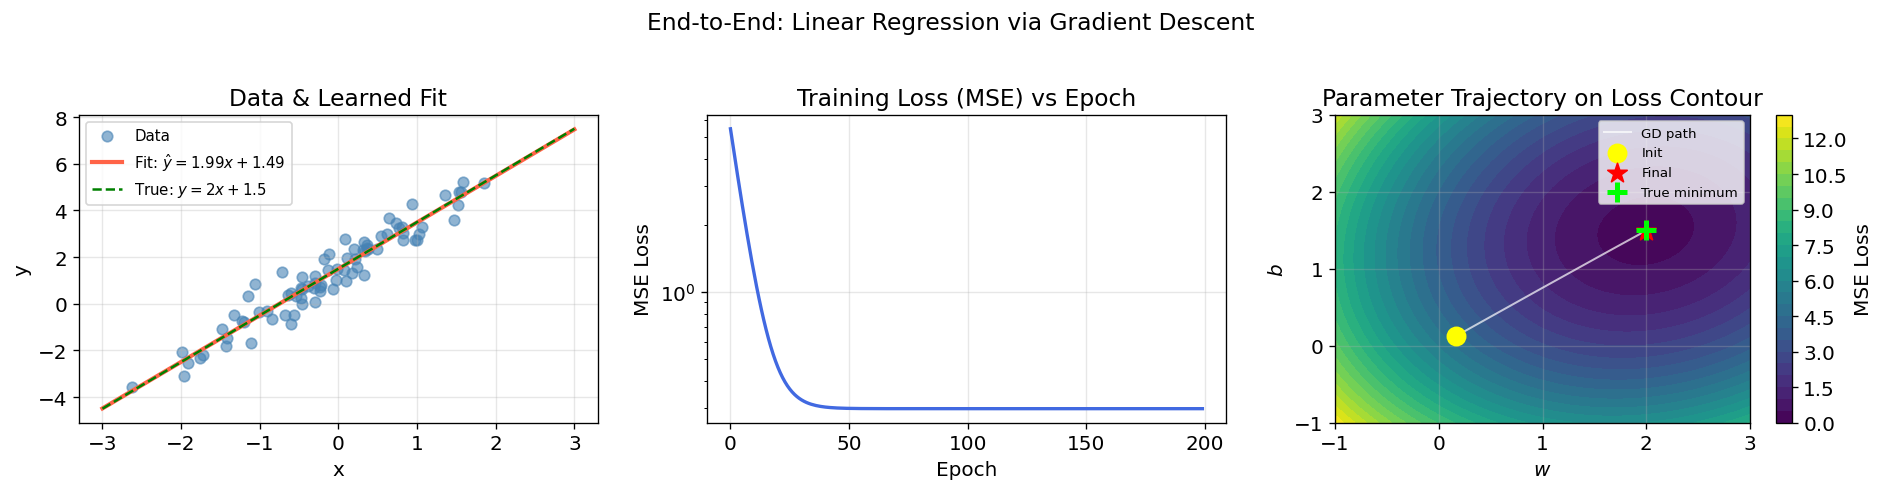

In [16]:
np.random.seed(42)
n = 80
X = np.random.randn(n)
y = 2.0*X + 1.5 + np.random.randn(n)*0.6   # true w=2, b=1.5

# ── Train with gradient descent ──
w, b = 0.0, 0.0
lr = 0.05
losses, ws, bs = [], [], []

for epoch in range(200):
    y_hat = w*X + b
    L = np.mean((y_hat - y)**2)
    
    dL_dw = (2/n) * np.sum((y_hat - y) * X)
    dL_db = (2/n) * np.sum(y_hat - y)
    
    w -= lr * dL_dw
    b -= lr * dL_db
    
    losses.append(L); ws.append(w); bs.append(b)

print(f"Final: w = {w:.4f} (true=2.0),  b = {b:.4f} (true=1.5),  Loss = {losses[-1]:.4f}")

# ── Visualise ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Data + final fit
ax = axes[0]
ax.scatter(X, y, alpha=0.6, label='Data', color='steelblue', s=40)
x_line = np.array([-3, 3])
ax.plot(x_line, w*x_line + b, 'tomato', lw=2.5, label=f'Fit: $\hat y={w:.2f}x+{b:.2f}$')
ax.plot(x_line, 2*x_line + 1.5, 'g--', lw=1.5, label='True: $y=2x+1.5$')
ax.set_title("Data & Learned Fit"); ax.legend(fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y')

# Loss curve
ax = axes[1]
ax.plot(losses, 'royalblue', lw=2)
ax.set_title("Training Loss (MSE) vs Epoch")
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_yscale('log')

# Parameter trajectory on contour
w_grid = np.linspace(-1, 3, 100)
b_grid = np.linspace(-1, 3, 100)
WW, BB = np.meshgrid(w_grid, b_grid)
LL = np.array([[np.mean((ww*X + bb - y)**2) for ww in w_grid] for bb in b_grid])

ax = axes[2]
cp = ax.contourf(WW, BB, LL, levels=30, cmap='viridis')
fig.colorbar(cp, ax=ax, label='MSE Loss')
ax.plot(ws, bs, 'white', lw=1.2, alpha=0.7, label='GD path')
ax.scatter(ws[0], bs[0], s=120, color='yellow', zorder=5, label='Init')
ax.scatter(ws[-1], bs[-1], s=150, color='red', zorder=5, marker='*', label='Final')
ax.scatter([2.0],[1.5], s=150, color='lime', zorder=5, marker='+', lw=3, label='True minimum')
ax.set_title("Parameter Trajectory on Loss Contour")
ax.set_xlabel('$w$'); ax.set_ylabel('$b$'); ax.legend(fontsize=8)

plt.suptitle("End-to-End: Linear Regression via Gradient Descent", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 🎓 Summary: Calculus of Optimization in ML

| Calculus Concept | What It Is | Where ML Uses It |
|---|---|---|
| **Derivative** | Rate of change of $f$ | Gradient computation |
| **Partial Derivative** | Rate w.r.t. one parameter | Multi-parameter models |
| **Gradient** $\nabla\mathcal{L}$ | Vector of all partials | GD update direction |
| **Chain Rule** | $(f\circ g)' = f'\cdot g'$ | **Backpropagation** |
| **Critical Points** | $\nabla\mathcal{L}=0$ | Convergence criterion |
| **Convexity** | $H \succeq 0$ | Loss landscape analysis |
| **Hessian** $H$ | Matrix of 2nd derivatives | Curvature, Adam, Newton |
| **Taylor Expansion** | Local quadratic approx | Justifies small $\eta$ steps |
| **Regularization** | Modified loss + penalty | L1/L2, weight decay |

### 🔑 The Big Picture

```
Input → Model(θ) → Prediction → Loss L(θ) 
          ↑________________________________|
          θ ← θ − η·∇L    (gradient descent)
                    ↑
               Chain Rule computes this
               (Backpropagation)
```

Every modern ML optimizer — SGD, Adam, RMSProp, AdaGrad — is a clever variant of this single calculus idea.
